## K-Means Cluster Analysis of Fidelity Fund Returns 
### University of Virginia
### DS 7200: Distributed Computing
### Last Updated: August 20, 2023

Sabine Segaloff

bhj3vc

## Instructions

In this assignment, you will conduct a k-means cluster analysis on a set of Fidelity mutual funds.  
This helps to group similar funds based on their performance (as opposed to their description, which is typical).  
The outline below will walk you through the required steps.  

This assignment is worth a total of **10 POINTS.**

## Data Details 

The file *fido_returns_funds_on_rows.csv* is the processed data for k-means. Additional details about this file: 
- Each row represents a mutual fund  
- Each column represents a trading day (these are used as features)  
- Each value represents the daily percentage change in price between the current trading day and previous trading day

### Load Modules and Read Data into Spark DataFrame

In [1]:
# load modules
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
spark = SparkSession.builder.getOrCreate()

from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.feature import VectorAssembler

# load data
df = spark.read.csv("fido_returns_funds_on_rows.csv", header=True, inferSchema=True)
# df.printSchema()

# get a look at the dimensions
print(len(df.columns))                      # number of columns
print(df.count())                           # number of rows
print(set(t for _, t in df.dtypes))         # the distinct column types

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/10/09 16:32:54 WARN Utils: Your hostname, Beans-Legion, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/10/09 16:32:54 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/home/sabine/projects/distributed_computing/.venv/lib/python3.13/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/10/09 16:32:54 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


1731
927
{'double'}


**(VALUE: 2 POINTS) Assemble the Features into a column. 
Show the first five rows of data ONLY for the features column.
(this should make things easier to read)**

In [2]:
# assemble features into a vector column so that spark's ml estimators can use them (they read input from a single column with one vector per row (named features by default))
assembler = VectorAssembler(inputCols=df.columns, outputCol="features") # every column is a feature here so I pass them all; df.columns gives a python list of strings
dataset = assembler.transform(df) # named to leave df untouched
dataset.select("features").show(n=5, truncate=50)

26/10/09 16:32:59 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+--------------------------------------------------+
|                                          features|
+--------------------------------------------------+
|[0.0,0.0,-0.0104071952,0.0036855078999999996,-0...|
|[0.0,0.0,-0.010516645,0.0037243991,-0.001239925...|
|[0.0,0.0,-0.010764366599999999,0.0037807228,-0....|
|[0.0,8.26105E-4,-0.0049668976,0.002486532600000...|
|[0.0,8.281574000000001E-4,-0.0049792634,0.00249...|
+--------------------------------------------------+
only showing top 5 rows


**(VALUE: 1 POINT) Set up the k-means model and train the model**  
Use parameters: 
- 3 clusters
- maximum of 10 iterations 
- seed=314

In [3]:
kmeans = KMeans().setK(3).setSeed(314).setMaxIter(10)
# could also do: KMeans(k=3, seed=314, maxIter=10)

model = kmeans.fit(dataset)

26/10/09 16:33:03 WARN DAGScheduler: Broadcasting large task binary with size 1006.3 KiB


**(VALUE: 2 POINTS) Compute and Print the Silhouette Score**  

In [4]:
predictions = model.transform(dataset)

# Evaluate clustering by computing Silhouette score
evaluator = ClusteringEvaluator()

silhouette = evaluator.evaluate(predictions) # give it predictions so it knows the points features and the assigned clusters
print("Silhouette with squared euclidean distance = " + str(silhouette))

print("Cluster Centers: ")
centers = model.clusterCenters()
print(len(centers), len(centers[0]))   # expect: 3 1731

Silhouette with squared euclidean distance = 0.42290918461227955
Cluster Centers: 
3 1731


Silhouette score of 0.4229 is positive, so the clusters are better than a random split, but its well below 1, so there is overlap.

Since this score is the average of s(i) over all points, the 0.4229 could be a mix of well and poorly placed points.

**(VALUE: 2 POINTS) Define a function `kmeans_range()` that does the following:**
- takes an integer representing the lower bound for k
- takes an integer representing the upper bound for k
- take a Spark DataFrame containing training data
- fit K-means with k ranging from lower bound to upper bound, inclusive  
- the other parameters should be the same as earlier 
- for each k, compute the silhouette score
- return a pandas dataframe with columns containing k, silhouette score (each row holds the score for given k)

In [5]:
def kmeans_range(lower, upper, features_df):
    """
    Fit k-means for each k in a range and score each fit.
    
    For every integer k from `lower` to `upper` (inclusive), fits KMeans
    with seed=314 and maxIter=10, then computes the silhouette score
    (ClusteringEvaluator's default, squared Euclidean distance).

    Args:
        lower: Smallest k to try (int).
        upper: Largest k to try (int); included in the range.
        features_df: Spark DataFrame with an assembled "features" vector column.

    Returns:
        pandas DataFrame with one row per k and columns "k" and "silhouette".
    """

    scores = []
    evaluator = ClusteringEvaluator() # evaluate; not dependent on k so create outside loop

    for k in range(lower, upper +1):
        kmeans = KMeans().setK(k).setSeed(314).setMaxIter(10)
        model = kmeans.fit(features_df) # fit
        predictions = model.transform(features_df) # transform
        score = evaluator.evaluate(predictions) # get silhouette score
        scores.append((k, score)) # append to list

    return pd.DataFrame(scores, columns=['k','silhouette']) # return pandas df made from list

**(VALUE: 1 POINT) Call `kmeans_range` to compute K-means with clusters ranging from 2 to 10 inclusive, printing the resulting dataframe.**

In [6]:
results = kmeans_range(2, 10, dataset)
print(results)

26/10/09 16:33:09 WARN DAGScheduler: Broadcasting large task binary with size 1006.3 KiB
26/10/09 16:33:11 WARN DAGScheduler: Broadcasting large task binary with size 1019.8 KiB
26/10/09 16:33:13 WARN DAGScheduler: Broadcasting large task binary with size 1033.4 KiB
26/10/09 16:33:15 WARN DAGScheduler: Broadcasting large task binary with size 1046.9 KiB
26/10/09 16:33:17 WARN DAGScheduler: Broadcasting large task binary with size 1060.5 KiB
26/10/09 16:33:19 WARN DAGScheduler: Broadcasting large task binary with size 1074.0 KiB
26/10/09 16:33:22 WARN DAGScheduler: Broadcasting large task binary with size 1087.5 KiB
26/10/09 16:33:24 WARN DAGScheduler: Broadcasting large task binary with size 1101.1 KiB


    k  silhouette
0   2    0.602396
1   3    0.422909
2   4    0.448951
3   5    0.459352
4   6    0.468879
5   7    0.459371
6   8    0.477168
7   9    0.431599
8  10    0.438814


k=3 aligns with the 0.4229 from earlier so that is good news. Looks like our highest score is at k=2. Second highest is k=8. k=2 stands out from the others, so the peak rule points to k=2.

**(VALUE: 1 POINT) Produce a plot with cluster numbers k on the x-axis, sihouette scores on the y-axis**

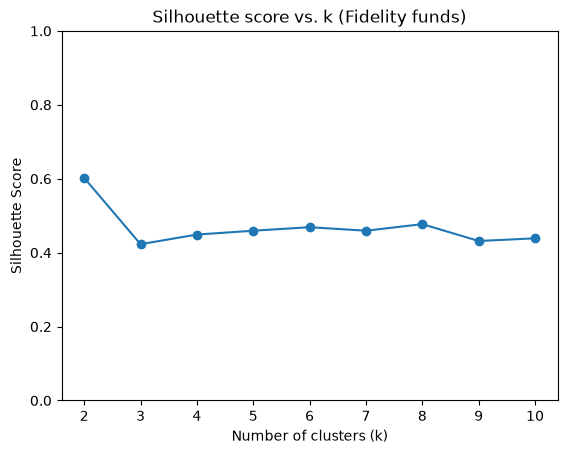

In [7]:
fig, ax = plt.subplots()
ax.plot(results["k"], results["silhouette"], marker="o")
ax.set_xlabel(xlabel='Number of clusters (k)')
ax.set_ylabel(ylabel='Silhouette Score')
ax.set_title("Silhouette score vs. k (Fidelity funds)")
ax.set_xticks(results["k"])
ax.set_ylim(0,1) # show the true scale

plt.show()

**(VALUE: 1 POINT) Based on how the silhouette score is calculated, what is its time complexity? (e.g., O(log n))**  
You can find the definition of the silhouette score in the lecture notes, for example. 

$O(n^2)$, where $n$ is the number of points. For each point, calculating silhouette score requires the point's distance to all $n-1$ other points, so it's about $n(n-1)$ distances in total.